# Notebook for finding the parameters where recall is 1 and runtime is good

In [67]:
import os
import sys
import itertools


def find_project_root(target_folder="masteroppgave"):
    """Find the absolute path of a folder by searching upward."""
    currentdir = os.path.abspath("__file__")  # Get absolute script path
    while True:
        if os.path.basename(currentdir) == target_folder:
            return currentdir  # Found the target folder
        parentdir = os.path.dirname(currentdir)
        if parentdir == currentdir:  # Stop at filesystem root
            return None
        currentdir = parentdir  # Move one level up

# Example usage
project_root = find_project_root("masteroppgave")

if project_root:
    sys.path.append(project_root)
    print(f"Project root found: {project_root}")
else:
    raise RuntimeError("Could not find 'masteroppgave' directory")

from utils.helpers.measure_similarities import *

Project root found: c:\Users\eivin\dev\masteroppgave


## Read Bucketing Runtime CSV

In [68]:
CITY = "porto"
BUCKETING_METHOD = "loose"
MEASURE = "dtw"
DATA_SIZE = [500]
SCHEME = "grid"


folder_path = f"../../results_hashed/runtimes/bucketing/{CITY}/true_trajectories/{BUCKETING_METHOD}/{MEASURE}/"
file_name = f"runtimes_bucketing({BUCKETING_METHOD})_(true_trajectories)_{CITY}_{MEASURE}_{DATA_SIZE}_{SCHEME}.csv"
file_path = folder_path + file_name

runtime_bucketing = pd.read_csv(file_path, index_col=0)
runtime_bucketing.head()



runtime_bucketing.head(5)

,Resolution,Layers,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
Measure,,,,,,,
dtw,0.1,1,500,4.299,6.896,0.020,11.215
dtw,0.1,2,500,4.461,0.632,0.041,5.134
dtw,0.1,3,500,4.616,1.000,0.064,5.680
dtw,0.1,4,500,4.826,1.157,0.093,6.076
dtw,0.1,5,500,5.033,1.496,0.120,6.649


## Read No Bucketing Runtime CSV

In [122]:
CITY = "porto"
MEASURE = "dtw"
DATA_SIZE = [500]
SCHEME = "grid"


folder_path = f"../../results_hashed/runtimes/no_bucketing/{CITY}/{MEASURE}/"
file_name = f"runtimes_{CITY}_{MEASURE}_{DATA_SIZE}_{SCHEME}_no_bucketing.csv"
file_path = folder_path + file_name

runtime_no_bucketing = pd.read_csv(file_path)
runtime_no_bucketing.head(5)


,City,Measure,Resolution,Layers,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Total time (Seconds)
0,porto,dtw,0.1,1,500,9.988,10.409,20.397
1,porto,dtw,0.1,2,500,19.814,0.697,20.511
2,porto,dtw,0.1,3,500,29.734,0.921,30.655
3,porto,dtw,0.1,4,500,39.680,1.315,40.995
4,porto,dtw,0.1,5,500,49.419,1.617,51.036


## Read No Bucketing Correlation

In [123]:
CITY = "porto"
MEASURE = "dtw"


folder_path = f"../../results_hashed/runtimes/no_bucketing/{CITY}/{MEASURE}/"
file_name = f"porto_no_bucketing_correlation_results.csv"
file_path = folder_path + file_name

correlation_no_bucketing = pd.read_csv(file_path, index_col=0)
correlation_no_bucketing.head(5)

#Merge runtime_no_bucketing and correlation_no_bucketing on columns "Resolution" and "Layers"
runtime_no_bucketing = pd.merge(runtime_no_bucketing, correlation_no_bucketing, on=["Resolution", "Layers"])
runtime_no_bucketing.head(5)


,City,Measure,Resolution,Layers,Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Total time (Seconds),Correlation
0,porto,dtw,0.1,1,500,9.988,10.409,20.397,0.796
1,porto,dtw,0.1,2,500,19.814,0.697,20.511,0.797
2,porto,dtw,0.1,3,500,29.734,0.921,30.655,0.803
3,porto,dtw,0.1,4,500,39.680,1.315,40.995,0.800
4,porto,dtw,0.1,5,500,49.419,1.617,51.036,0.800


## Read Bucket Evaluation CSV

In [124]:
CITY = "porto"
BUCKETING_METHOD = "loose"
MEASURE = "dtw"
DATA_SIZE = 500
SCHEME = "grid"

folder_path = f"../../results_hashed/bucket_evaluation/{BUCKETING_METHOD}/"
file_name = f"{CITY}_{MEASURE}_{SCHEME}_{DATA_SIZE}_{BUCKETING_METHOD}.csv"
file_path = folder_path + file_name

bucket_evaluation = pd.read_csv(file_path, index_col=0)

bucket_evaluation.head(5)

,Measure,Resolution,Layers,Size,Threshold,Avg Precision,Avg Recall,Avg F1 Score,Avg Total Buckets,Avg Largest Bucket Size,Avg Smallest Bucket Size,Avg Buckets with >1 Trajectory,Avg Buckets with 1 Trajectory,Avg Percentage >1 Trajectory,Avg Percentage 1 Trajectory,Avg Correlation Coefficient,Avg Total Comparisons,Avg Total Skipped Comparisons,Avg Num Compared Trajectories
City,,,,,,,,,,,,,,,,,,,
porto,dtw,0.1,1,500,0.1,0.014,1.000,0.028,1584.292,119.625,1.0,1140.375,443.917,71.983,28.017,0.849,41239.375,126565.958,497.833
porto,dtw,0.1,1,500,0.2,0.053,0.991,0.100,1584.292,119.625,1.0,1140.375,443.917,71.983,28.017,0.849,41239.375,126565.958,497.833
porto,dtw,0.1,1,500,0.3,0.122,0.961,0.216,1584.292,119.625,1.0,1140.375,443.917,71.983,28.017,0.849,41239.375,126565.958,497.833
porto,dtw,0.1,1,500,0.4,0.217,0.899,0.349,1584.292,119.625,1.0,1140.375,443.917,71.983,28.017,0.849,41239.375,126565.958,497.833
porto,dtw,0.1,1,500,0.5,0.325,0.831,0.468,1584.292,119.625,1.0,1140.375,443.917,71.983,28.017,0.849,41239.375,126565.958,497.833


In [125]:
# First, filter the bucket_evaluation dataframe
filtered_eval = bucket_evaluation[
    (bucket_evaluation["Avg Recall"] == 1) &
    (bucket_evaluation["Threshold"] == 0.1)
]

# Select only the necessary columns from runtime_bucketing
runtime_selected = runtime_bucketing[[
    "Resolution", "Layers",
    "Average Similarity Computation Time (Seconds)",
    "Average Hash Generation Time (Seconds)",
    "Average Bucket Distribution Time (Seconds)",
    "Total time (Seconds)"
]]

# Merge using only Diameter, Layers, and Disks as keys
runtime_bucketing_and_bucket_evaluation = filtered_eval.merge(
    runtime_selected,
    on=["Resolution", "Layers"],
    how="left"
)

columns_to_show = [
    "Resolution", "Layers",
    "Avg Correlation Coefficient",
    "Avg Recall", "Threshold",
    "Average Similarity Computation Time (Seconds)",
    "Average Hash Generation Time (Seconds)",
    "Average Bucket Distribution Time (Seconds)",
    "Total time (Seconds)"
]

runtime_bucketing_and_bucket_evaluation.head(5)



,Measure,Resolution,Layers,Size,Threshold,Avg Precision,Avg Recall,Avg F1 Score,Avg Total Buckets,Avg Largest Bucket Size,...,Avg Percentage >1 Trajectory,Avg Percentage 1 Trajectory,Avg Correlation Coefficient,Avg Total Comparisons,Avg Total Skipped Comparisons,Avg Num Compared Trajectories,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
0,dtw,0.1,1,500,0.1,0.014,1.0,0.028,1584.292,119.625,...,71.983,28.017,0.849,41239.375,126565.958,497.833,4.299,6.896,0.020,11.215
1,dtw,0.1,2,500,0.1,0.014,1.0,0.027,3170.333,123.417,...,71.972,28.028,0.852,85848.667,291570.583,498.083,4.461,0.632,0.041,5.134
2,dtw,0.1,3,500,0.1,0.013,1.0,0.026,4751.542,124.083,...,72.158,27.842,0.851,130221.000,457588.583,498.083,4.616,1.000,0.064,5.680
3,dtw,0.1,4,500,0.1,0.013,1.0,0.026,6336.583,125.167,...,72.068,27.932,0.854,175858.833,625460.833,498.167,4.826,1.157,0.093,6.076
4,dtw,0.1,5,500,0.1,0.013,1.0,0.026,7926.750,126.625,...,72.033,27.967,0.854,221044.167,793217.667,498.208,5.033,1.496,0.120,6.649


In [139]:
# Sort the merged dataframe by Avg Correlation Coefficient in descending order
runtime_bucketing_and_bucket_evaluation_sorted = runtime_bucketing_and_bucket_evaluation.sort_values(
    by="Total time (Seconds)",
    ascending=True
)
runtime_bucketing_and_bucket_evaluation_sorted.head(10)

#show only these columns
columns_to_show = [
    "Resolution", "Layers",
    "Avg Correlation Coefficient",
    "Avg Recall", "Threshold",
    "Average Similarity Computation Time (Seconds)",
    "Average Hash Generation Time (Seconds)",
    "Average Bucket Distribution Time (Seconds)",
    "Total time (Seconds)"
]
runtime_bucketing_and_bucket_evaluation_sorted = runtime_bucketing_and_bucket_evaluation_sorted[columns_to_show]

#extract lowest runtime Total time (Seconds) in the runtime_bucketing_and_bucket_evaluation_sorted dataframe
lowest_runtime = runtime_bucketing_and_bucket_evaluation_sorted.iloc[0]

lowest_runtime = runtime_bucketing_and_bucket_evaluation_sorted["Total time (Seconds)"].min()


print(lowest_runtime)


runtime_bucketing_and_bucket_evaluation_sorted.head(5)



5.025


,Resolution,Layers,Avg Correlation Coefficient,Avg Recall,Threshold,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
6,0.2,1,0.808,1.0,0.1,4.806,0.206,0.013,5.025
1,0.1,2,0.852,1.0,0.1,4.461,0.632,0.041,5.134
7,0.2,2,0.810,1.0,0.1,4.949,0.333,0.026,5.308
12,0.3,1,0.783,1.0,0.1,5.420,0.155,0.009,5.584
8,0.2,3,0.816,1.0,0.1,5.091,0.472,0.039,5.602


In [127]:
runtime_no_bucketing.head(5)


# Merge runtime_no_bucketing with merged_df_sorted top 5 rows
runtime_no_bucketing_vs_runtime_bucketing = runtime_bucketing_and_bucket_evaluation_sorted.head(5)
runtime_no_bucketing_vs_runtime_bucketing = runtime_no_bucketing_vs_runtime_bucketing.merge(
    runtime_no_bucketing,
    on=["Resolution", "Layers"],
    how="left",
    suffixes=("", "_no_bucketing")
)
# Rename the columns to avoid confusion
runtime_no_bucketing_vs_runtime_bucketing.rename(
    columns={
        "Average Similarity Computation Time (Seconds)": "Average Similarity Computation Time (Seconds)_bucketing",
        "Average Hash Generation Time (Seconds)": "Average Hash Generation Time (Seconds)_bucketing",
        "Average Bucket Distribution Time (Seconds)": "Average Bucket Distribution Time (Seconds)_bucketing",
        "Total time (Seconds)": "Total time (Seconds)_bucketing"
    },
    inplace=True
)




runtime_no_bucketing_vs_runtime_bucketing.head()


,Resolution,Layers,Avg Correlation Coefficient,Avg Recall,Threshold,Average Similarity Computation Time (Seconds)_bucketing,Average Hash Generation Time (Seconds)_bucketing,Average Bucket Distribution Time (Seconds)_bucketing,Total time (Seconds)_bucketing,City,Measure,Size,Average Similarity Computation Time (Seconds)_no_bucketing,Average Hash Generation Time (Seconds)_no_bucketing,Total time (Seconds)_no_bucketing,Correlation
0,0.2,1,0.808,1.0,0.1,4.806,0.206,0.013,5.025,porto,dtw,500,4.676,0.210,4.886,0.754
1,0.1,2,0.852,1.0,0.1,4.461,0.632,0.041,5.134,porto,dtw,500,19.814,0.697,20.511,0.797
2,0.2,2,0.810,1.0,0.1,4.949,0.333,0.026,5.308,porto,dtw,500,9.363,0.367,9.730,0.762
3,0.3,1,0.783,1.0,0.1,5.420,0.155,0.009,5.584,porto,dtw,500,2.832,0.185,3.017,0.749
4,0.2,3,0.816,1.0,0.1,5.091,0.472,0.039,5.602,porto,dtw,500,14.058,0.525,14.583,0.767


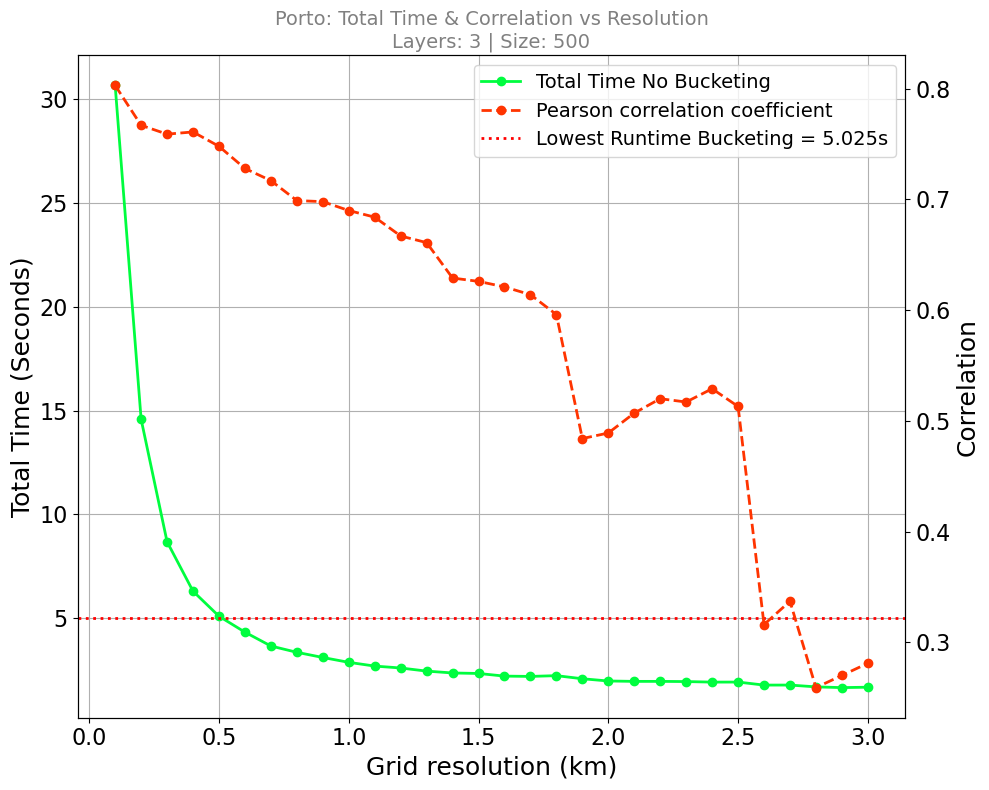

In [156]:
# Filter the runtime_no_bucketing dataframe to only include the rows where Layers = 3
filtered_runtime_no_bucketing = runtime_no_bucketing[runtime_no_bucketing["Layers"] == 3]

filtered_runtime_no_bucketing.head(5)


import matplotlib.pyplot as plt
import numpy as np

def plot_total_time_vs_resolution(
    df,
    city: str,
    measure: str = "dtw",
    layers: int = 3,
    size: int = 500,
    lowest_runtime: float = None,  # Add this argument
):
    """
    Plots the relationship between grid resolution and total time (in seconds),
    and overlays correlation on a secondary y-axis with clear labels.
    Adds a horizontal line for the externally provided lowest total runtime.
    """

    # Filter the DataFrame
    filtered = df[
        (df['City'] == city) &
        (df['Measure'] == measure) &
        (df['Layers'] == layers) &
        (df['Size'] == size)
    ].sort_values(by='Resolution')

    # Extract values
    res = filtered['Resolution'].values
    total_time = filtered['Total time (Seconds)'].values
    corr = filtered['Correlation'].astype(float).values

    # Plot
    fig, ax1 = plt.subplots(figsize=(10, 8), dpi=100)
    ax2 = ax1.twinx()
    cmap = plt.get_cmap("gist_ncar")

    line1 = ax1.plot(res, total_time, color=cmap(0.3), marker='o', lw=2, label='Total Time No Bucketing')[0]
    line2 = ax2.plot(res, corr, color=cmap(0.7), marker='o', lw=2, linestyle='--', label='Pearson correlation coefficient')[0]

    # Use provided lowest_runtime if available
    if lowest_runtime is not None:
        line3 = ax1.axhline(
            y=lowest_runtime,
            color='red',
            linestyle=':',
            linewidth=2,
            label=f'Lowest Runtime Bucketing = {lowest_runtime:.3f}s'
        )
        lines = [line1, line2, line3]
    else:
        lines = [line1, line2]

    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="upper right", fontsize=14)

    # Axis labels and styling
    ax1.set_xlabel("Grid resolution (km)", fontsize=18)
    ax1.set_ylabel("Total Time (Seconds)", fontsize=18)
    ax2.set_ylabel("Correlation", fontsize=18)

    ax1.tick_params(axis="both", which="major", labelsize=16)
    ax2.tick_params(axis="both", which="major", labelsize=16)

    ax1.set_title(
        f"{city.capitalize()}: Total Time & Correlation vs Resolution\nLayers: {layers} | Size: {size}",
        fontsize=14,
        color='grey'
    )

    ax1.grid(True)
    fig.tight_layout()
    plt.show()




plot_total_time_vs_resolution(
    filtered_runtime_no_bucketing,
    city="porto",
    measure="dtw",
    layers=3,
    size=500,
    lowest_runtime=lowest_runtime  # Pass the value from your earlier cell
)


# filtered_runtime_no_bucketing.head(5)
